In [ ]:
import os
import sys

import logging

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import argparse
import dataclasses
import xarray as xr
import numpy as np
import pandas as pd
from datetime import datetime
from tqdm import tqdm

import jax
import optax

from graphcast import checkpoint, data_utils, rollout, graphcast, normalization
import save_params_utils
import setup_jax_functions
from plotting import scale, select, plot_data, save_animation, save_static_plot
from metrics import compute_rmse, compute_mae, compute_bias, compute_acc
import matplotlib.pyplot as plt
# import pynvml
import time

current_date = datetime.now().strftime("%Y-%m-%d_%H-%M")

# jax.config.update('jax_disable_jit', True)

# for memory efficiency
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE']='false'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '2.0' 
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform"

mean_by_level = None
stddev_by_level = None
diffs_stddev_by_level = None
model_config = None
task_config = None
params = None
state = None

def generate_sample_era5_dataset(
    date='2022-01-01', 
    model_config = None,
    task_config = None,
    time_steps=4
):
    """
    Generate a sample ERA5 dataset with random values matching original specifications.
    
    Parameters:
    - date: Base date for the dataset
    - lon_res: Longitude resolution
    - lat_res: Latitude resolution
    - levels: Number of vertical levels
    - time_steps: Number of time steps
    
    Returns:
    xr.Dataset with random values
    """
    lons = np.arange(0, 360, model_config.resolution)
    lats = np.arange(-90, 90 + model_config.resolution, model_config.resolution)
    # if task_config.levels == 13:
    level_values = np.array(task_config.pressure_levels)
    # level_values = np.array([1, 2, 3, 5, 7, 10, 20, 30, 50, 70, 100, 125, 150, 175, 200, 
    #                           225, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 
    #                           750, 775, 800, 825, 850, 875, 900, 925, 950, 975, 1000])
    times = pd.timedelta_range(start='0 days', periods=time_steps, freq='6h')
    
    base_datetime = pd.to_datetime(date)

    base_datetime = pd.to_datetime(date)
    datetime_coords = np.array([base_datetime + pd.Timedelta(t) for t in times])
    
    ds = xr.Dataset(
        data_vars={
            'geopotential_at_surface': (['lat', 'lon'], np.random.uniform(20000, 30000, size=(len(lats), len(lons)))),
            'land_sea_mask': (['lat', 'lon'], np.random.choice([0.0, 1.0], size=(len(lats), len(lons)))),
            '2m_temperature': (['batch', 'time', 'lat', 'lon'], np.random.uniform(240, 310, size=(1, len(times), len(lats), len(lons)))),
            'mean_sea_level_pressure': (['batch', 'time', 'lat', 'lon'], np.random.uniform(95000, 105000, size=(1, len(times), len(lats), len(lons)))),
            '10m_v_component_of_wind': (['batch', 'time', 'lat', 'lon'], np.random.uniform(-10, 10, size=(1, len(times), len(lats), len(lons)))),
            '10m_u_component_of_wind': (['batch', 'time', 'lat', 'lon'], np.random.uniform(-10, 10, size=(1, len(times), len(lats), len(lons)))),
            'total_precipitation_6hr': (['batch', 'time', 'lat', 'lon'], np.random.uniform(0, 0.01, size=(1, len(times), len(lats), len(lons)))),
            'toa_incident_solar_radiation': (['batch', 'time', 'lat', 'lon'], np.random.uniform(0, 2000000, size=(1, len(times), len(lats), len(lons)))),
            'temperature': (['batch', 'time', 'level', 'lat', 'lon'], np.random.uniform(250, 300, size=(1, len(times), len(level_values), len(lats), len(lons)))),
            'geopotential': (['batch', 'time', 'level', 'lat', 'lon'], np.random.uniform(0, 500000, size=(1, len(times), len(level_values), len(lats), len(lons)))),
            'u_component_of_wind': (['batch', 'time', 'level', 'lat', 'lon'], np.random.uniform(-10, 10, size=(1, len(times), len(level_values), len(lats), len(lons)))),
            'v_component_of_wind': (['batch', 'time', 'level', 'lat', 'lon'], np.random.uniform(-10, 10, size=(1, len(times), len(level_values), len(lats), len(lons)))),
            'vertical_velocity': (['batch', 'time', 'level', 'lat', 'lon'], np.random.uniform(-1, 1, size=(1, len(times), len(level_values), len(lats), len(lons)))),
            'specific_humidity': (['batch', 'time', 'level', 'lat', 'lon'], np.random.uniform(0, 0.01, size=(1, len(times), len(level_values), len(lats), len(lons))))
        },
        coords={
            'lon': lons,
            'lat': lats,
            'level': level_values,
            'time': times,
            'datetime': (['batch', 'time'], datetime_coords.reshape(1, -1)),
            'batch': [0]
        }
    )
    
    return ds


# modify the gradients function signature (needed for finetuning with optax)
def grads_fn(params, state, inputs, targets, forcings, model_config, task_config):
    def _aux(params, state, i, t, f):
        (loss, diagnostics), next_state = setup_jax_functions.loss_fn.apply(params, state, jax.random.PRNGKey(0), model_config, task_config, i, t, f)
        return loss, (diagnostics, next_state)
    (loss, (diagnostics, next_state)), grads = jax.value_and_grad(_aux, has_aux=True)(params, state, inputs, targets, forcings)
    return loss, diagnostics, next_state, grads


In [10]:
imerg_data = xr.open_dataset('/Datastorage/saptarishi.dhanuka_asp25/imerg_data/combined_imerg_20150701_20240929.nc4')
test_imerg = imerg_data.sel(time=slice('2015-09-01', '2015-12-01'))
test_imerg

<xarray.Dataset> Size: 96MB
Dimensions:        (time: 92, lon: 361, lat: 181)
Coordinates:
  * time           (time) datetime64[ns] 736B 2015-09-01 ... 2015-12-01
  * lat            (lat) float64 1kB 90.0 89.0 88.0 87.0 ... -88.0 -89.0 -90.0
  * lon            (lon) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0 180.0
Data variables:
    precipitation  (time, lon, lat) float64 48MB ...
    randomError    (time, lon, lat) float64 48MB ...
Attributes:
    BeginDate:       2015-07-01
    BeginTime:       00:00:00.000Z
    EndDate:         2015-07-01
    EndTime:         23:59:59.999Z
    FileHeader:      StartGranuleDateTime=2015-07-01T00:00:00.000Z;\nStopGran...
    InputPointer:    3B-HHR.MS.MRG.3IMERG.20150701-S000000-E002959.0000.V07B....
    title:           GPM IMERG Final Precipitation L3 1 day 0.1 degree x 0.1 ...
    DOI:             10.5067/GPM/IMERGDF/DAY/07
    ProductionTime:  2023-12-18T15:32:13.665Z

In [16]:
wb_data_orig = xr.open_zarr("/Datastorage/saptarishi.dhanuka_asp25/era5_data/wb_era5_jun_sept_2015_temp_ppt.zarr")
wb_data = wb_data_orig.sel(time=slice('2015-09-01', '2015-09-30'))

In [74]:
imerg_test = xr.open_dataset("/Datastorage/saptarishi.dhanuka_asp25/era5_imerg_20150701-2015_india_full_globe.nc").sel(time=slice('2015-09-01T06:00:00.000000000', '2015-09-30'))
imerg_test = imerg_test.rename({'latitude': 'lat', 'longitude': 'lon'})
imerg_test

<xarray.Dataset> Size: 7GB
Dimensions:                  (time: 119, lat: 181, lon: 360, level: 37)
Coordinates:
  * lat                      (lat) float32 724B -90.0 -89.0 -88.0 ... 89.0 90.0
  * level                    (level) int64 296B 1 2 3 5 7 ... 925 950 975 1000
  * lon                      (lon) float32 1kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
  * time                     (time) datetime64[ns] 952B 2015-09-01T06:00:00 ....
Data variables: (12/13)
    10m_u_component_of_wind  (time, lat, lon) float32 31MB ...
    10m_v_component_of_wind  (time, lat, lon) float32 31MB ...
    2m_temperature           (time, lat, lon) float32 31MB ...
    geopotential             (time, level, lat, lon) float32 1GB ...
    geopotential_at_surface  (lat, lon) float32 261kB ...
    land_sea_mask            (lat, lon) float32 261kB ...
    ...                       ...
    specific_humidity        (time, level, lat, lon) float32 1GB ...
    temperature              (time, level, lat, lon) float32 1GB ...
    total_precipitation_6hr  (time, lat, lon) float32 31MB ...
    u_component_of_wind      (time, level, lat, lon) float32 1GB ...
    v_component_of_wind      (time, level, lat, lon) float32 1GB ...
    vertical_velocity        (time, level, lat, lon) float32 1GB ...

In [11]:
inits = 4

In [85]:
global mean_by_level
global stddev_by_level
global diffs_stddev_by_level
global model_config
global task_config
global params
global state

log_file = f"loggers/printing_logs{current_date}.log"
logging.basicConfig(filename=log_file, level=logging.INFO, format="%(asctime)s - %(message)s")
logger = logging.getLogger()
logger.info("Starting the script")

model_levels = 13
model_resolution = 1.0
if model_levels == 37:
    filename = '/Datastorage/saptarishi.dhanuka_asp25/gc_weights/graphcast_0.25_37.npz'
        
elif model_resolution == 0.25:
    filename = '/Datastorage/saptarishi.dhanuka_asp25/gc_weights/graphcast_0.25_13.npz'
    
    with open(f'/Datastorage/saptarishi.dhanuka_asp25/era5_data/graphcast_dataset_source-era5_date-2022-01-01_res-{args.model_resolution}_levels-13_steps-12.nc', 'rb') as f:
        logger.info("Loading Dataset")
        tik = datetime.now()
        training_trial_batch = xr.load_dataset(f).compute()
        tok = datetime.now()
        logger.info(f"Dataset loaded in {tok - tik}")

else:

    filename = '/Datastorage/saptarishi.dhanuka_asp25/gc_weights/origs/graphcast_1_13.npz'
    dataset_name = "/Datastorage/saptarishi.dhanuka_asp25/era5_data/arco_era5_1.0_formatted.nc"

    arco = wb_data
    
    old_lats = arco['latitude'].values
    old_lons = arco['longitude'].values
    new_lats = np.arange(-90.0, 90.0 + 1e-8, 1.0)
    new_lats = np.flip(new_lats)
    new_lons = np.arange(0, 359.75 + 1e-8, 1.0)
    arco = arco.interp({'latitude': new_lats, 'longitude': new_lons}, 
                            method='linear',
                            kwargs={'fill_value': None})
    
    input_vars = ['10m_u_component_of_wind',
                'geopotential_at_surface',
                '10m_v_component_of_wind',
                'specific_humidity',
                'land_sea_mask',
                'vertical_velocity',
                'geopotential',
                'v_component_of_wind',
                'temperature',
                'total_precipitation_6hr',
                'mean_sea_level_pressure',
                '2m_temperature',
                'u_component_of_wind']
    
    # arco = arco.drop_vars(['toa_incident_solar_radiation',
    # 'year_progress_sin',
    # 'year_progress_cos',
    # 'day_progress_sin',
    # 'day_progress_cos','cos_latitude',
    # 'cos_longitude','sin_longitude'])

    # arco = arco.rename({'total_precipitation': 'total_precipitation_6hr'})

    arco = arco.expand_dims(batch=1)
    arco = arco.rename({'latitude': 'lat', 'longitude': 'lon'})

    datetime_array = arco['time'].values
    # Calculate the time coordinate in 6-hour increments (in nanoseconarco)
    time_array = np.arange(0, len(datetime_array) * 21600000000000, 21600000000000, dtype='timedelta64[ns]')

    # Add the new 'time' coordinate to the dataset
    arco1 = arco.assign_coords(datetime=('time', time_array))

    temp_time = arco1.coords["time"].copy()
    temp_datetime = arco1.coords["datetime"].copy()

    # Reassign the coordinates, swapping their values
    arco1 = arco1.assign_coords(
        time=temp_datetime,
        datetime=temp_time
    )

    logger.info("Coordinates first time")
    logger.info(arco1)
    logger.info("\n")
    logger.info(arco1.coords)
    logger.info("\n")


    # arco1['geopotential_at_surface'] = arco1['geopotential_at_surface'].isel(batch=0, time=0)
    # arco1['land_sea_mask'] = arco1['land_sea_mask'].isel(batch=0, time=0)

    old_datetime = arco1["datetime"].values  # shape (1489,)

    # For our purposes, we want the coordinate to have shape (batch, time). Since the batch
    # dimension is of length 1, we can simply add a new axis.
    new_datetime = old_datetime[np.newaxis, :]  # shape becomes (1, 1489)

    # Now, reassign the "datetime" coordinate to have dims ("batch", "time").
    arco1 = arco1.assign_coords(datetime=(("batch", "time"), new_datetime))

    print(f"Coordinates after reassigning: {arco1.coords}\n")


    logger.info(arco1.nbytes)

    select_time = arco1.isel(time=slice(0, 240))
    tik = datetime.now()

    select_time_eval = arco1

    eval_trial_batch = select_time_eval.load()



    select_time_evals = [imerg_test.isel(time=slice(i*26, i*28+30)) for i in range(inits)]


    print(f"Eval batch first time: {eval_trial_batch.time.values}")
    # training_trial_batch = select_time.load()

    tok = datetime.now()
    # training_trial_batch = training_trial_batch.rename({'time': 'datetime'})
    logger.info("Training batch time")
    # logger.info(training_trial_batch.coords)
    logger.info(f"Dataset loaded in {tok - tik}")

    # with open("/Datastorage/saptarishi.dhanuka_asp25/era5_data/dataset_source-era5_date-2022-01-01_res-1.0_levels-13_steps-40.nc", 'rb') as f:
    #     print("Loading Dataset")
    #     tik = datetime.now()
    #     training_trial_batch = xr.load_dataset(f).compute()
    #     # training_trial_batch = training_trial_batch.isel(time=slice(0, 12))
    #     # training_trial_batch = training_trial_batch.rename({'time': 'datetime'})
    #     print("Training batch time")
    #     print(training_trial_batch.datetime)
    #     tok = datetime.now()
    #     print(f"Dataset loaded in {tok - tik}")


with open(filename, 'rb') as f:
    ckpt = checkpoint.load(f, graphcast.CheckPoint)

params = ckpt.params


with open('/Datastorage/saptarishi.dhanuka_asp25/gc_norms/diffs_stddev_by_level.nc', 'rb') as f:
    diffs_stddev_by_level = xr.load_dataset(f).compute()
with open('/Datastorage/saptarishi.dhanuka_asp25/gc_norms/stddev_by_level.nc', 'rb') as f:
    stddev_by_level = xr.load_dataset(f).compute()
with open('/Datastorage/saptarishi.dhanuka_asp25/gc_norms/mean_by_level.nc', 'rb') as f:
    mean_by_level = xr.load_dataset(f).compute()


state = {}
model_config = ckpt.model_config
task_config = ckpt.task_config
logger.info(model_config)
logger.info(task_config)
setup_jax_functions.configs['model_config'] = model_config
setup_jax_functions.configs['task_config'] = task_config
setup_jax_functions.configs['state'] = state
setup_jax_functions.configs['params'] = params
setup_jax_functions.configs['stddev_by_level'] = stddev_by_level
setup_jax_functions.configs['diffs_stddev_by_level'] = diffs_stddev_by_level
setup_jax_functions.configs['mean_by_level'] = mean_by_level

setup_jax_functions.update_configs({
    'params': ckpt.params,
    'state': {},
    'model_config': ckpt.model_config,
    'task_config': ckpt.task_config,
    'mean_by_level': mean_by_level,
    'stddev_by_level': stddev_by_level,
    'diffs_stddev_by_level': diffs_stddev_by_level
})

init_jitted = jax.jit(setup_jax_functions.with_configs(setup_jax_functions.run_forward.init))
loss_fn_jitted = setup_jax_functions.drop_state(setup_jax_functions.with_params(jax.jit(setup_jax_functions.with_configs(setup_jax_functions.loss_fn.apply))))
grads_fn_jitted = setup_jax_functions.with_params(jax.jit(setup_jax_functions.with_configs(setup_jax_functions.grads_fn)))
run_forward_jitted = setup_jax_functions.drop_state(setup_jax_functions.with_params(jax.jit(setup_jax_functions.with_configs(
    setup_jax_functions.run_forward.apply))))

def run_model(params, state, inputs, targets_template, forcings):
    predictions = run_forward_jitted(
        rng=jax.random.PRNGKey(0),
        inputs=inputs,
        targets_template=targets_template,
        forcings=forcings,
        params=params,
        state=state
    )
    return predictions


Coordinates after reassigning: Coordinates:
  * level     (level) int64 104B 50 100 150 200 250 300 ... 600 700 850 925 1000
  * lat       (lat) float64 1kB 90.0 89.0 88.0 87.0 ... -87.0 -88.0 -89.0 -90.0
  * lon       (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
    datetime  (batch, time) datetime64[ns] 960B 2015-09-01 ... 2015-09-30T18:...
  * time      (time) timedelta64[ns] 960B 0 days 00:00:00 ... 29 days 18:00:00

Eval batch first time: [               0   21600000000000   43200000000000   64800000000000
   86400000000000  108000000000000  129600000000000  151200000000000
  172800000000000  194400000000000  216000000000000  237600000000000
  259200000000000  280800000000000  302400000000000  324000000000000
  345600000000000  367200000000000  388800000000000  410400000000000
  432000000000000  453600000000000  475200000000000  496800000000000
  518400000000000  540000000000000  561600000000000  583200000000000
  604800000000000  626400000000000  648000000000

In [78]:
select_time_evals[-1]

<xarray.Dataset> Size: 2GB
Dimensions:                  (time: 36, lat: 181, lon: 360, level: 37)
Coordinates:
  * lat                      (lat) float32 724B -90.0 -89.0 -88.0 ... 89.0 90.0
  * level                    (level) int64 296B 1 2 3 5 7 ... 925 950 975 1000
  * lon                      (lon) float32 1kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
  * time                     (time) datetime64[ns] 288B 2015-09-20T18:00:00 ....
Data variables: (12/13)
    10m_u_component_of_wind  (time, lat, lon) float32 9MB ...
    10m_v_component_of_wind  (time, lat, lon) float32 9MB ...
    2m_temperature           (time, lat, lon) float32 9MB ...
    geopotential             (time, level, lat, lon) float32 347MB ...
    geopotential_at_surface  (lat, lon) float32 261kB ...
    land_sea_mask            (lat, lon) float32 261kB ...
    ...                       ...
    specific_humidity        (time, level, lat, lon) float32 347MB ...
    temperature              (time, level, lat, lon) float32 347MB ...
    total_precipitation_6hr  (time, lat, lon) float32 9MB ...
    u_component_of_wind      (time, level, lat, lon) float32 347MB ...
    v_component_of_wind      (time, level, lat, lon) float32 347MB ...
    vertical_velocity        (time, level, lat, lon) float32 347MB ...

In [79]:

new_params_path = "/Datastorage/saptarishi.dhanuka_asp25/gc_weights/finetuned/graphcast_1_13_imerg26_4_2015.npz"

f = open(new_params_path, "rb")
new_ckpt = checkpoint.load(f, graphcast.CheckPoint)
new_params = new_ckpt.params

In [82]:
eval_trial_batch

<xarray.Dataset> Size: 5GB
Dimensions:                  (batch: 1, time: 120, lat: 181, lon: 360, level: 13)
Coordinates:
  * level                    (level) int64 104B 50 100 150 200 ... 850 925 1000
  * lat                      (lat) float64 1kB 90.0 89.0 88.0 ... -89.0 -90.0
  * lon                      (lon) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
    datetime                 (batch, time) datetime64[ns] 960B 2015-09-01 ......
  * time                     (time) timedelta64[ns] 960B 0 days 00:00:00 ... ...
Dimensions without coordinates: batch
Data variables: (12/13)
    10m_u_component_of_wind  (batch, time, lat, lon) float64 63MB -0.2194 ......
    10m_v_component_of_wind  (batch, time, lat, lon) float64 63MB -0.09066 .....
    2m_temperature           (batch, time, lat, lon) float64 63MB 270.7 ... 2...
    geopotential             (batch, time, level, lat, lon) float64 813MB 2.0...
    geopotential_at_surface  (batch, lat, lon) float64 521kB -0.07617 ... 2.7...
    land_sea_mask            (batch, lat, lon) float64 521kB 0.0 0.0 ... 1.0 1.0
    ...                       ...
    specific_humidity        (batch, time, level, lat, lon) float64 813MB 2.8...
    temperature              (batch, time, level, lat, lon) float64 813MB 225...
    total_precipitation_6hr  (batch, time, lat, lon) float64 63MB 0.0001923 ....
    u_component_of_wind      (batch, time, level, lat, lon) float64 813MB 0.0...
    v_component_of_wind      (batch, time, level, lat, lon) float64 813MB -0....
    vertical_velocity        (batch, time, level, lat, lon) float64 813MB 0.0...

In [111]:
select_time_evals_copy = select_time_evals.copy()
df_test = select_time_evals_copy[0].copy()
df_test

<xarray.Dataset> Size: 2GB
Dimensions:                  (time: 30, lat: 181, lon: 360, level: 37)
Coordinates:
  * lat                      (lat) float32 724B -90.0 -89.0 -88.0 ... 89.0 90.0
  * level                    (level) int64 296B 1 2 3 5 7 ... 925 950 975 1000
  * lon                      (lon) float32 1kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
  * time                     (time) datetime64[ns] 240B 2015-09-01T06:00:00 ....
Data variables: (12/13)
    10m_u_component_of_wind  (time, lat, lon) float32 8MB 1.076 1.076 ... 0.1165
    10m_v_component_of_wind  (time, lat, lon) float32 8MB 0.1421 0.1421 ... 0.15
    2m_temperature           (time, lat, lon) float32 8MB 219.7 219.7 ... 270.4
    geopotential             (time, level, lat, lon) float32 289MB 4.178e+05 ...
    geopotential_at_surface  (lat, lon) float32 261kB 2.735e+04 ... -0.07617
    land_sea_mask            (lat, lon) float32 261kB 1.0 1.0 1.0 ... 0.0 0.0
    ...                       ...
    specific_humidity        (time, level, lat, lon) float32 289MB 3.621e-06 ...
    temperature              (time, level, lat, lon) float32 289MB 248.6 ... ...
    total_precipitation_6hr  (time, lat, lon) float32 8MB 0.0 0.0 ... 0.0008679
    u_component_of_wind      (time, level, lat, lon) float32 289MB 0.001011 ....
    v_component_of_wind      (time, level, lat, lon) float32 289MB -0.0006561...
    vertical_velocity        (time, level, lat, lon) float32 289MB 0.0002674 ...

In [112]:

for i in tqdm(range(4)):
    arco = select_time_evals_copy[i]
    arco = arco.expand_dims(batch=1)

    datetime_array = arco['time'].values
    # Calculate the time coordinate in 6-hour increments (in nanoseconarco)
    time_array = np.arange(0, len(datetime_array) * 21600000000000, 21600000000000, dtype='timedelta64[ns]')

    # Add the new 'time' coordinate to the dataset
    arco1 = arco.assign_coords(datetime=('time', time_array))

    temp_time = arco1.coords["time"].copy()
    temp_datetime = arco1.coords["datetime"].copy()

    # Reassign the coordinates, swapping their values
    arco1 = arco1.assign_coords(
        time=temp_datetime,
        datetime=temp_time
    )


    # arco1['geopotential_at_surface'] = arco1['geopotential_at_surface'].isel(batch=0, time=0)
    # arco1['land_sea_mask'] = arco1['land_sea_mask'].isel(batch=0, time=0)

    old_datetime = arco1["datetime"].values  # shape (1489,)

    # For our purposes, we want the coordinate to have shape (batch, time). Since the batch
    # dimension is of length 1, we can simply add a new axis.
    new_datetime = old_datetime[np.newaxis, :]  # shape becomes (1, 1489)

    # Now, reassign the "datetime" coordinate to have dims ("batch", "time").
    arco1 = arco1.assign_coords(datetime=(("batch", "time"), new_datetime))

    select_time_evals_copy[i] = arco1

100%|██████████| 4/4 [00:00<00:00, 400.85it/s]


In [113]:
select_time_evals_copy[0]

<xarray.Dataset> Size: 2GB
Dimensions:                  (batch: 1, time: 30, lat: 181, lon: 360, level: 37)
Coordinates:
  * lat                      (lat) float32 724B -90.0 -89.0 -88.0 ... 89.0 90.0
  * level                    (level) int64 296B 1 2 3 5 7 ... 925 950 975 1000
  * lon                      (lon) float32 1kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
    datetime                 (batch, time) datetime64[ns] 240B 2015-09-01T06:...
  * time                     (time) timedelta64[ns] 240B 0 days 00:00:00 ... ...
Dimensions without coordinates: batch
Data variables: (12/13)
    10m_u_component_of_wind  (batch, time, lat, lon) float32 8MB 1.076 ... 0....
    10m_v_component_of_wind  (batch, time, lat, lon) float32 8MB 0.1421 ... 0.15
    2m_temperature           (batch, time, lat, lon) float32 8MB 219.7 ... 270.4
    geopotential             (batch, time, level, lat, lon) float32 289MB 4.1...
    geopotential_at_surface  (batch, lat, lon) float32 261kB 2.735e+04 ... -0...
    land_sea_mask            (batch, lat, lon) float32 261kB 1.0 1.0 ... 0.0 0.0
    ...                       ...
    specific_humidity        (batch, time, level, lat, lon) float32 289MB 3.6...
    temperature              (batch, time, level, lat, lon) float32 289MB 248...
    total_precipitation_6hr  (batch, time, lat, lon) float32 8MB 0.0 ... 0.00...
    u_component_of_wind      (batch, time, level, lat, lon) float32 289MB 0.0...
    v_component_of_wind      (batch, time, level, lat, lon) float32 289MB -0....
    vertical_velocity        (batch, time, level, lat, lon) float32 289MB 0.0...

In [105]:
arco1

<xarray.Dataset> Size: 2GB
Dimensions:                  (batch: 1, time: 30, lat: 181, lon: 360, level: 37)
Coordinates:
  * lat                      (lat) float32 724B -90.0 -89.0 -88.0 ... 89.0 90.0
  * level                    (level) int64 296B 1 2 3 5 7 ... 925 950 975 1000
  * lon                      (lon) float32 1kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
    datetime                 (batch, time) datetime64[ns] 240B 2015-09-01T06:...
  * time                     (time) timedelta64[ns] 240B 0 days 00:00:00 ... ...
Dimensions without coordinates: batch
Data variables: (12/13)
    10m_u_component_of_wind  (batch, time, lat, lon) float32 8MB 1.076 ... 0....
    10m_v_component_of_wind  (batch, time, lat, lon) float32 8MB 0.1421 ... 0.15
    2m_temperature           (batch, time, lat, lon) float32 8MB 219.7 ... 270.4
    geopotential             (batch, time, level, lat, lon) float32 289MB 4.1...
    geopotential_at_surface  (batch, lat, lon) float32 261kB 2.735e+04 ... -0...
    land_sea_mask            (batch, lat, lon) float32 261kB 1.0 1.0 ... 0.0 0.0
    ...                       ...
    specific_humidity        (batch, time, level, lat, lon) float32 289MB 3.6...
    temperature              (batch, time, level, lat, lon) float32 289MB 248...
    total_precipitation_6hr  (batch, time, lat, lon) float32 8MB 0.0 ... 0.00...
    u_component_of_wind      (batch, time, level, lat, lon) float32 289MB 0.0...
    v_component_of_wind      (batch, time, level, lat, lon) float32 289MB -0....
    vertical_velocity        (batch, time, level, lat, lon) float32 289MB 0.0...

In [114]:
for i in tqdm(range(inits)):
    eval_inputs, eval_targets, eval_forcings = data_utils.extract_inputs_targets_forcings(
    select_time_evals_copy[i].load(), target_lead_times=slice("6h", "168h"),
    **dataclasses.asdict(task_config))

    assert eval_trial_batch.sizes["time"] >= 3

    logger.info(f"Eval batch time dimensions: {eval_trial_batch.sizes['time']}")

    task_config_dict =  dataclasses.asdict(task_config)
    # task_config_dict.pop('input_duration')

    print("Eval Inputs:   ", eval_inputs.dims.mapping)
    print("Eval Targets:  ", eval_targets.dims.mapping)
    print("Eval Forcings: ", eval_forcings.dims.mapping)

    targets_template = eval_targets * np.nan

    print("Running old params")
    predictions_old = run_model(params, state, eval_inputs, targets_template, eval_forcings)

    print("Predictions Old: ", predictions_old.dims.mapping)


    print("Running new params")

    predictions_finetuned = run_model(new_params, state, eval_inputs, targets_template, eval_forcings)
    print("Predictions Finetuned: ", predictions_finetuned.dims.mapping)


    predictions_old.to_netcdf(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_old_india2015_2015_{i}_imerg.nc")
    predictions_finetuned.to_netcdf(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_finetuned_india2015_full_2015_{i}_imerg.nc")

  0%|          | 0/4 [00:00<?, ?it/s]

Eval Inputs:    {'batch': 1, 'time': 2, 'lat': 181, 'lon': 360, 'level': 13}
Eval Targets:   {'batch': 1, 'time': 28, 'lat': 181, 'lon': 360, 'level': 13}
Eval Forcings:  {'batch': 1, 'time': 28, 'lat': 181, 'lon': 360}
Running old params
Predictions Old:  {'time': 28, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}
Running new params
Predictions Finetuned:  {'time': 28, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}


 25%|██▌       | 1/4 [01:32<04:36, 92.18s/it]

Eval Inputs:    {'batch': 1, 'time': 2, 'lat': 181, 'lon': 360, 'level': 13}
Eval Targets:   {'batch': 1, 'time': 28, 'lat': 181, 'lon': 360, 'level': 13}
Eval Forcings:  {'batch': 1, 'time': 28, 'lat': 181, 'lon': 360}
Running old params
Predictions Old:  {'time': 28, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}
Running new params
Predictions Finetuned:  {'time': 28, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}


 50%|█████     | 2/4 [03:00<03:00, 90.15s/it]

Eval Inputs:    {'batch': 1, 'time': 2, 'lat': 181, 'lon': 360, 'level': 13}
Eval Targets:   {'batch': 1, 'time': 28, 'lat': 181, 'lon': 360, 'level': 13}
Eval Forcings:  {'batch': 1, 'time': 28, 'lat': 181, 'lon': 360}
Running old params
Predictions Old:  {'time': 28, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}
Running new params
Predictions Finetuned:  {'time': 28, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}


 75%|███████▌  | 3/4 [04:29<01:29, 89.49s/it]

Eval Inputs:    {'batch': 1, 'time': 2, 'lat': 181, 'lon': 360, 'level': 13}
Eval Targets:   {'batch': 1, 'time': 28, 'lat': 181, 'lon': 360, 'level': 13}
Eval Forcings:  {'batch': 1, 'time': 28, 'lat': 181, 'lon': 360}
Running old params
Predictions Old:  {'time': 28, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}
Running new params
Predictions Finetuned:  {'time': 28, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}


100%|██████████| 4/4 [05:58<00:00, 89.62s/it]


In [122]:
select_time_evals_copy[0]

<xarray.Dataset> Size: 2GB
Dimensions:                  (batch: 1, time: 30, lat: 181, lon: 360, level: 37)
Coordinates:
  * lat                      (lat) float32 724B -90.0 -89.0 -88.0 ... 89.0 90.0
  * level                    (level) int64 296B 1 2 3 5 7 ... 925 950 975 1000
  * lon                      (lon) float32 1kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
    datetime                 (batch, time) datetime64[ns] 240B 2015-09-01T06:...
  * time                     (time) timedelta64[ns] 240B 0 days 00:00:00 ... ...
Dimensions without coordinates: batch
Data variables: (12/13)
    10m_u_component_of_wind  (batch, time, lat, lon) float32 8MB 1.076 ... 0....
    10m_v_component_of_wind  (batch, time, lat, lon) float32 8MB 0.1421 ... 0.15
    2m_temperature           (batch, time, lat, lon) float32 8MB 219.7 ... 270.4
    geopotential             (batch, time, level, lat, lon) float32 289MB 4.1...
    geopotential_at_surface  (batch, lat, lon) float32 261kB 2.735e+04 ... -0...
    land_sea_mask            (batch, lat, lon) float32 261kB 1.0 1.0 ... 0.0 0.0
    ...                       ...
    specific_humidity        (batch, time, level, lat, lon) float32 289MB 3.6...
    temperature              (batch, time, level, lat, lon) float32 289MB 248...
    total_precipitation_6hr  (batch, time, lat, lon) float32 8MB 0.0 ... 0.00...
    u_component_of_wind      (batch, time, level, lat, lon) float32 289MB 0.0...
    v_component_of_wind      (batch, time, level, lat, lon) float32 289MB -0....
    vertical_velocity        (batch, time, level, lat, lon) float32 289MB 0.0...

In [123]:
import cartopy.crs as ccrs
import xarray as xr

latmax = 38
latmin = 6
lonmin = 68
lonmax = 98

def plot_difference_with_targets_fine_sims(preds_finetuned, targets, time_step, var_name):
    fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    extent = [68, 98, 6, 38]  # Focus on India

    temperature_pred_finetuned = preds_finetuned[var_name]
    temperature_targets = targets[var_name]

    # Difference between finetuned predictions and evaluation targets
    temp_finetuned = temperature_pred_finetuned.isel(time=time_step).sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax)).squeeze()
    temp_targets = temperature_targets.isel(time=time_step).sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax)).squeeze()
    difference = temp_finetuned - temp_targets

    difference.plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(), cmap='bwr',
        cbar_kwargs={'label': 'Temperature Difference (K)'})
    ax.set_extent(extent)
    ax.coastlines()
    ax.set_title(f"Finetuned Prediction vs Ground Truth at Time Step {time_step}")

    plt.tight_layout()
    plt.savefig(f'plotsnew/training/difference_finetuned{time_step}_imerg1.png')
    plt.close()

    return (difference)



def plot_difference_with_targets_base_sims(preds_old, targets, time_step, var_name):
    fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    extent = [68, 98, 6, 38]  # Focus on India

    temperature_pred_old = preds_old[var_name]
    temperature_targets = targets[var_name]

    # Difference between finetuned predictions and evaluation targets
    temp_base = temperature_pred_old.isel(time=time_step).sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax)).squeeze()
    temp_targets = temperature_targets.isel(time=time_step).sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax)).squeeze()
    difference = temp_base - temp_targets

    difference.plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(), cmap='bwr',
        cbar_kwargs={'label': 'Temperature Difference (K)'})
    ax.set_extent(extent)
    ax.coastlines()
    ax.set_title(f"Finetuned Prediction vs Ground Truth at Time Step {time_step}")

    plt.tight_layout()
    plt.savefig(f'plotsnew/training/difference_base{time_step}_imerg1.png')
    plt.close()

    return (difference)

  0%|          | 0/4 [00:00<?, ?it/s]/tmp/ipykernel_1785906/1916270725.py:7: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  predictions_old = xr.open_dataset(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_old_india2015_2015_{i}_imerg.nc")
/tmp/ipykernel_1785906/1916270725.py:8: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  predictions_finetuned = xr.open_dataset(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_finetuned_india2015_full_2015_{i}_imerg.nc")
100%|██████████| 7/7 [00:01<00:00,  5.66it/s]


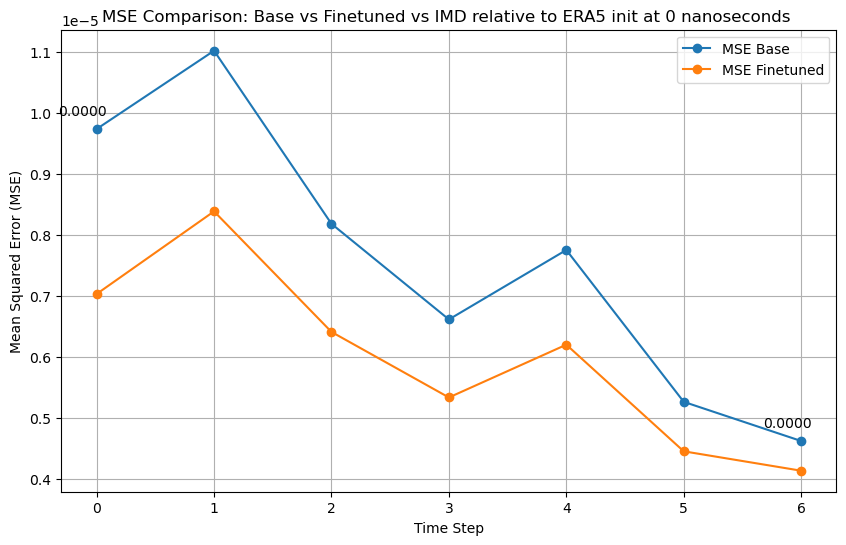

 25%|██▌       | 1/4 [00:02<00:07,  2.62s/it]/tmp/ipykernel_1785906/1916270725.py:7: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  predictions_old = xr.open_dataset(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_old_india2015_2015_{i}_imerg.nc")
/tmp/ipykernel_1785906/1916270725.py:8: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  predictions_finetuned = xr.open_dataset(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_finetuned_india2015_full_2015_{i}_imerg.nc")
100%|██████████| 7/7 [00:01<00:00,  5.93it/s]


<Figure size 640x480 with 0 Axes>

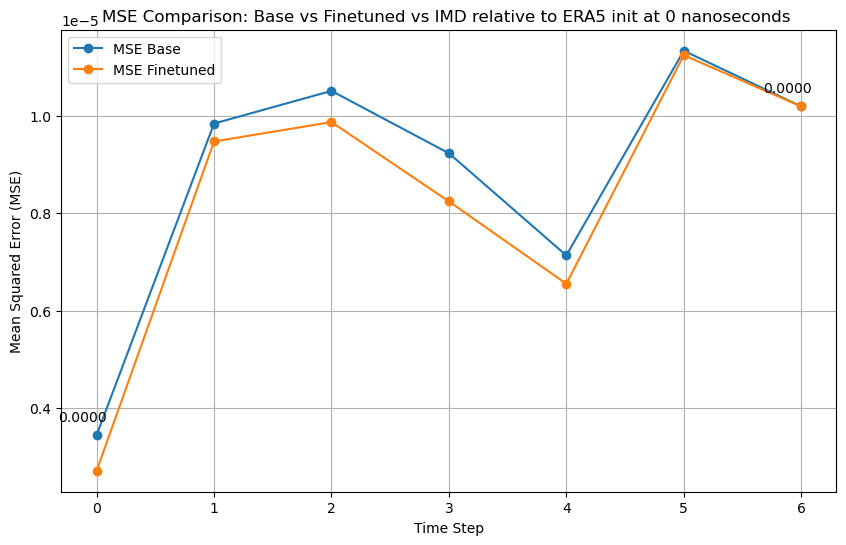

 50%|█████     | 2/4 [00:04<00:04,  2.42s/it]/tmp/ipykernel_1785906/1916270725.py:7: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  predictions_old = xr.open_dataset(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_old_india2015_2015_{i}_imerg.nc")
/tmp/ipykernel_1785906/1916270725.py:8: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  predictions_finetuned = xr.open_dataset(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_finetuned_india2015_full_2015_{i}_imerg.nc")
100%|██████████| 7/7 [00:01<00:00,  5.74it/s]


<Figure size 640x480 with 0 Axes>

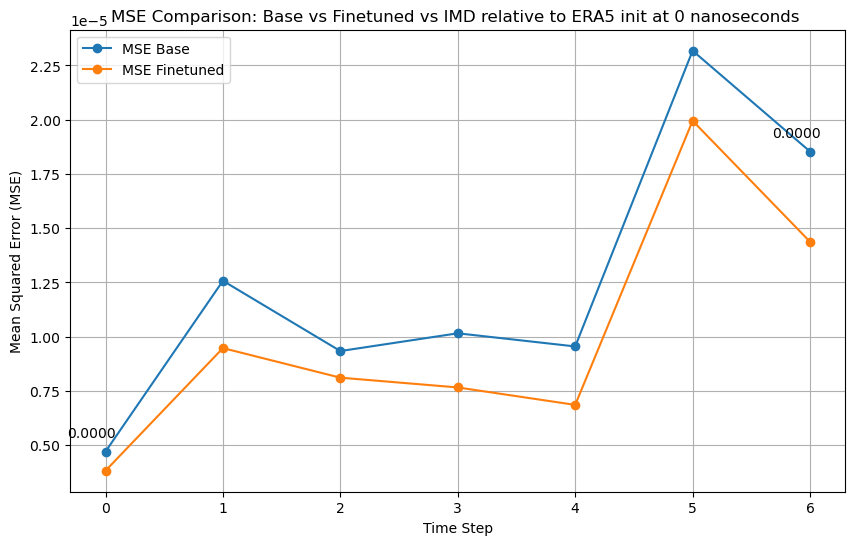

 75%|███████▌  | 3/4 [00:07<00:02,  2.59s/it]/tmp/ipykernel_1785906/1916270725.py:7: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  predictions_old = xr.open_dataset(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_old_india2015_2015_{i}_imerg.nc")
/tmp/ipykernel_1785906/1916270725.py:8: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  predictions_finetuned = xr.open_dataset(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_finetuned_india2015_full_2015_{i}_imerg.nc")
100%|██████████| 7/7 [00:01<00:00,  5.71it/s]


<Figure size 640x480 with 0 Axes>

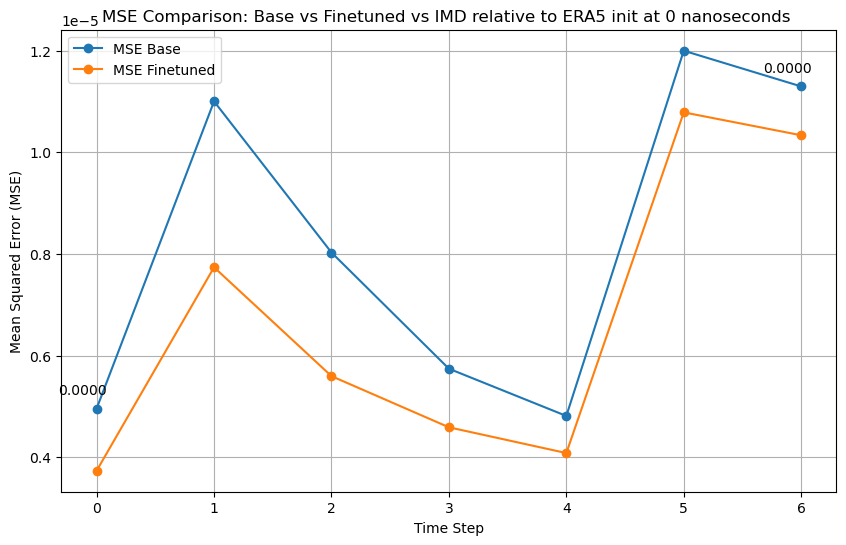

100%|██████████| 4/4 [00:10<00:00,  2.62s/it]


<Figure size 640x480 with 0 Axes>

In [128]:
import cartopy.crs as ccrs
from datetime import datetime
current_date = datetime.now().strftime("%Y-%m-%d_%H-%M")

#iterates over the initialization of the model
for i in tqdm(range(inits)):
    predictions_old = xr.open_dataset(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_old_india2015_2015_{i}_imerg.nc")
    predictions_finetuned = xr.open_dataset(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_finetuned_india2015_full_2015_{i}_imerg.nc")
    eval_inputs, eval_targets, eval_forcings = data_utils.extract_inputs_targets_forcings(
    select_time_evals_copy[i].load(), target_lead_times=slice("6h", "168h"),
    **dataclasses.asdict(task_config))

    variable_name = 'total_precipitation_6hr'
    
    # Plot differences with ground truth for each time step
    differences_finetuned = []
    differences_base = []
    differences_era5_imd = []
    for time_step in tqdm(range(7)):
        differences_finetuned.append(plot_difference_with_targets_fine_sims(predictions_finetuned,eval_targets,time_step, variable_name))
        differences_base.append(plot_difference_with_targets_base_sims(predictions_old,eval_targets,time_step, variable_name))
        # differences_era5_imd.append(plot_diff_imd_era5(time_step))

    # print(differences_finetuned)
    # print(differences_base)

    # print("Finetuned differences: ", differences_finetuned)
    # print("Base differences: ", differences_base)
    


    def compute_mse(predictions, targets):
        return ((predictions - targets) ** 2).mean()

    def compute_mse_diffs(diff):
        return (diff ** 2).mean(dim=["lat", "lon"]).values

    # Compute the MSE for each time step and aggregate
    mse_finetuned = []
    mse_base = []
    mse_imd_era5 = []
    for j in range(len(differences_finetuned)):
        mse_diff_finetuned = compute_mse_diffs(differences_finetuned[j])
        mse_diff_base = compute_mse_diffs(differences_base[j])
        # mse_diff_imd_era5 = compute_mse_diffs(differences_era5_imd[i])
        
        mse_finetuned.append(mse_diff_finetuned)
        mse_base.append(mse_diff_base)

    # print(mse_base)
    # print()
    # print(mse_finetuned)



    
    # Plot the line chart
    plt.figure(figsize=(10, 6))
    plt.plot(list(range(7)), mse_base, label='MSE Base', marker='o')
    plt.plot(list(range(7)), mse_finetuned, label='MSE Finetuned', marker='o')
    # plt.plot(time_steps, mse_imd_era5, label='MSE IMD ERA5', marker='x')

        # Annotate the first and last points for MSE Base
    plt.annotate(f"{mse_base[0]:.4f}", (0, mse_base[0]), textcoords="offset points", xytext=(-10, 10), ha='center')
    plt.annotate(f"{mse_base[-1]:.4f}", (6, mse_base[-1]), textcoords="offset points", xytext=(-10, 10), ha='center')


    # Add labels, title, and legend
    plt.xlabel('Time Step')
    plt.ylabel('Mean Squared Error (MSE)')
    plt.title(f'MSE Comparison: Base vs Finetuned vs IMD relative to ERA5 init at {select_time_evals_copy[i].time.values[0]} ')
    plt.legend()
    plt.grid(True)

    # Show the plot
    plt.show()
    # plt.savefig(f"./final_plots/metrics/mse_comparison_finetuned_base_{i}_{current_date}.png")
    plt.clf()


The graphcast will still need to be initialised over the whole world with the era5 data but we can then separately eval with multiple simulations on the imerg data

In [14]:
select_time_eval

<xarray.Dataset> Size: 3GB
Dimensions:                  (batch: 1, time: 64, lat: 181, lon: 360, level: 13)
Coordinates:
  * level                    (level) int64 104B 50 100 150 200 ... 850 925 1000
  * lat                      (lat) float64 1kB 90.0 89.0 88.0 ... -89.0 -90.0
  * lon                      (lon) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
    datetime                 (batch, time) datetime64[ns] 512B 2015-06-02T18:...
  * time                     (time) timedelta64[ns] 512B 1 days 18:00:00 ... ...
Dimensions without coordinates: batch
Data variables: (12/13)
    10m_u_component_of_wind  (batch, time, lat, lon) float64 33MB -0.4316 ......
    10m_v_component_of_wind  (batch, time, lat, lon) float64 33MB -0.4835 ......
    2m_temperature           (batch, time, lat, lon) float64 33MB 272.8 ... 2...
    geopotential             (batch, time, level, lat, lon) float64 434MB 2.0...
    geopotential_at_surface  (batch, lat, lon) float64 521kB -0.07617 ... 2.7...
    land_sea_mask            (batch, lat, lon) float64 521kB 0.0 0.0 ... 1.0 1.0
    ...                       ...
    specific_humidity        (batch, time, level, lat, lon) float64 434MB 2.7...
    temperature              (batch, time, level, lat, lon) float64 434MB 229...
    total_precipitation_6hr  (batch, time, lat, lon) float64 33MB 0.0001008 ....
    u_component_of_wind      (batch, time, level, lat, lon) float64 434MB -0....
    v_component_of_wind      (batch, time, level, lat, lon) float64 434MB 0.0...
    vertical_velocity        (batch, time, level, lat, lon) float64 434MB -0....

In [19]:

new_params_path = "/Datastorage/saptarishi.dhanuka_asp25/gc_weights/finetuned/graphcast_1_13_imerg26_4_2015.npz"

f = open(new_params_path, "rb")
new_ckpt = checkpoint.load(f, graphcast.CheckPoint)
new_params = new_ckpt.params

In [ ]:
jax.config.update("jax_enable_x64", True)


In [22]:
eval_trial_batch

<xarray.Dataset> Size: 5GB
Dimensions:                  (batch: 1, time: 120, lat: 181, lon: 360, level: 13)
Coordinates:
  * level                    (level) int64 104B 50 100 150 200 ... 850 925 1000
  * lat                      (lat) float64 1kB 90.0 89.0 88.0 ... -89.0 -90.0
  * lon                      (lon) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
    datetime                 (batch, time) datetime64[ns] 960B 2015-09-01 ......
  * time                     (time) timedelta64[ns] 960B 0 days 00:00:00 ... ...
Dimensions without coordinates: batch
Data variables: (12/13)
    10m_u_component_of_wind  (batch, time, lat, lon) float64 63MB -0.2194 ......
    10m_v_component_of_wind  (batch, time, lat, lon) float64 63MB -0.09066 .....
    2m_temperature           (batch, time, lat, lon) float64 63MB 270.7 ... 2...
    geopotential             (batch, time, level, lat, lon) float64 813MB 2.0...
    geopotential_at_surface  (batch, lat, lon) float64 521kB -0.07617 ... 2.7...
    land_sea_mask            (batch, lat, lon) float64 521kB 0.0 0.0 ... 1.0 1.0
    ...                       ...
    specific_humidity        (batch, time, level, lat, lon) float64 813MB 2.8...
    temperature              (batch, time, level, lat, lon) float64 813MB 225...
    total_precipitation_6hr  (batch, time, lat, lon) float64 63MB 0.0001923 ....
    u_component_of_wind      (batch, time, level, lat, lon) float64 813MB 0.0...
    v_component_of_wind      (batch, time, level, lat, lon) float64 813MB -0....
    vertical_velocity        (batch, time, level, lat, lon) float64 813MB 0.0...

In [24]:
eval_inputs, eval_targets, eval_forcings = data_utils.extract_inputs_targets_forcings(
eval_trial_batch, target_lead_times=slice("6h", "168h"),
**dataclasses.asdict(task_config))

targets_template = eval_targets * np.nan


In [25]:
predictions_old = run_model(params, state, eval_inputs, targets_template, eval_forcings)

print("Predictions Old: ", predictions_old.dims.mapping)

Predictions Old:  {'time': 28, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}


In [26]:
print("Running new params")

predictions_finetuned = run_model(new_params, state, eval_inputs, targets_template, eval_forcings)
print("Predictions Finetuned: ", predictions_finetuned.dims.mapping)


Running new params
Predictions Finetuned:  {'time': 28, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}


In [27]:
predictions_old.to_netcdf("/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_old_imerg_sept2015.nc")
predictions_finetuned.to_netcdf("/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_finetuned_imerg_sept2015.nc")

In [30]:
import cartopy.crs as ccrs

# Extract the variable of interest (e.g., '2m_variable')
variable_name = 'total_precipitation_6hr'
variable_pred_old = predictions_old[variable_name]
variable_pred_finetuned = predictions_finetuned[variable_name]
variable_targets = eval_targets[variable_name]

In [39]:
variable_pred_finetuned

<xarray.DataArray 'total_precipitation_6hr' (time: 28, batch: 1, lat: 181,
                                             lon: 360)> Size: 15MB
xarray_jax.JaxArrayWrapper(Array([[[[ 1.17241309e-04,  1.17241309e-04,  1.16777323e-04, ...,
           1.21881169e-04,  1.12369456e-04,  1.19097253e-04],
         [ 1.50223086e-04,  1.50687072e-04,  1.59966792e-04, ...,
           1.63345630e-04,  1.57578870e-04,  1.60726376e-04],
         [ 1.15560122e-04,  1.17186596e-04,  1.17057522e-04, ...,
           1.16512926e-04,  1.09393522e-04,  1.16717563e-04],
         ...,
         [ 1.99625730e-05,  1.18428183e-05,  1.74106501e-05, ...,
           1.03348639e-05,  1.67146711e-05,  1.38727570e-05],
         [ 2.14705274e-05,  2.72703521e-05,  2.04265589e-05, ...,
           1.52067167e-05,  1.91505975e-05,  2.37904573e-05],
         [ 5.87976861e-05,  6.52934898e-05,  5.62457632e-05, ...,
           5.36938403e-05,  5.85656931e-05,  5.87976861e-05]]],


       [[[ 1.70831689e-04,  1.69207738e-04,  1.68743752e-04, ...,
           1.75703542e-04,  1.73615605e-04,  1.71527668e-04],
         [ 1.76438294e-04,  1.77250270e-04,  1.84790042e-04, ...,
           1.89096852e-04,  1.81706141e-04,  1.75805921e-04],
         [ 1.41079351e-04,  1.40617888e-04,  1.41416786e-04, ...,
...
           4.75161850e-07,  2.56309875e-06, -3.36813613e-07],
         [-4.86493536e-05, -5.09112853e-05, -5.83350610e-05, ...,
          -5.50871591e-05, -4.66194150e-05, -5.48551661e-05],
         [ 6.05376335e-05,  4.55740857e-05,  4.35441470e-05, ...,
           4.81260085e-05,  4.94599682e-05,  4.34281505e-05]]],


       [[[ 1.05177673e-04,  1.02683749e-04,  1.00769806e-04, ...,
           1.00073828e-04,  9.20120711e-05,  1.03205733e-04],
         [ 2.11237242e-04,  2.15181123e-04,  2.07757348e-04, ...,
           2.28187671e-04,  2.26828777e-04,  2.12808802e-04],
         [ 1.13588181e-04,  1.06630915e-04,  9.96580483e-05, ...,
           1.18368870e-04,  1.26097017e-04,  1.19385482e-04],
         ...,
         [ 2.15285256e-05,  2.52404135e-05,  1.31187798e-05, ...,
           1.32927745e-05,  1.54387097e-05,  1.48587272e-05],
         [-7.60245264e-05, -7.38785912e-05, -8.26943248e-05, ...,
          -7.99104090e-05, -7.53865457e-05, -7.57345352e-05],
         [-2.57637586e-05, -3.79433905e-05, -4.18292731e-05, ...,
          -2.98236359e-05, -3.12735921e-05, -2.98816341e-05]]]],      dtype=float64))
Coordinates:
  * time     (time) timedelta64[ns] 224B 0 days 06:00:00 ... 7 days 00:00:00
  * lat      (lat) float64 1kB 90.0 89.0 88.0 87.0 ... -87.0 -88.0 -89.0 -90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
Dimensions without coordinates: batch

In [44]:
imerg_test = xr.open_dataset("/Datastorage/saptarishi.dhanuka_asp25/era5_imerg_20150701-2015_india_full_globe.nc").sel(time=slice('2015-09-01T06:00:00.000000000', '2015-09-30'))
imerg_test = imerg_test.rename({'latitude': 'lat', 'longitude': 'lon'})

In [57]:
latmax = 38
latmin = 6
lonmin = 68
lonmax = 98

def plot_difference_with_targets_fine(preds_finetuned, targets, time_step, var_name):
    fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    extent = [68, 98, 6, 38]  # Focus on India

    temperature_pred_finetuned = preds_finetuned[var_name]
    temperature_targets = targets[var_name]

    # Difference between finetuned predictions and evaluation targets
    temp_finetuned = temperature_pred_finetuned.isel(time=time_step).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze()
    imerg_targets = temperature_targets.isel(time=time_step).sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax)).squeeze()
    difference = temp_finetuned - imerg_targets

    difference.plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(), cmap='bwr',
        cbar_kwargs={'label': 'Temperature Difference (K)'})
    ax.set_extent(extent)
    ax.coastlines()
    ax.set_title(f"Finetuned Prediction vs Ground Truth at Time Step {time_step}")

    plt.tight_layout()
    plt.savefig(f'plotsnew/training/difference_finetuned{time_step}_imerg.png')
    plt.close()

    return (difference)



def plot_difference_with_targets_base(preds_old, targets, time_step, var_name):
    fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    extent = [68, 98, 6, 38]  # Focus on India

    temperature_pred_old = preds_old[var_name]
    temperature_targets = targets[var_name]

    # Difference between finetuned predictions and evaluation targets
    temp_base = temperature_pred_old.isel(time=time_step).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax)).squeeze()
    imerg_targets = temperature_targets.isel(time=time_step).sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax)).squeeze()
    difference = temp_base - imerg_targets

    difference.plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(), cmap='bwr',
        cbar_kwargs={'label': 'Temperature Difference (K)'})
    ax.set_extent(extent)
    ax.coastlines()
    ax.set_title(f"Finetuned Prediction vs Ground Truth at Time Step {time_step}")

    plt.tight_layout()
    plt.savefig(f'plotsnew/training/difference_base{time_step}_imerg.png')
    plt.close()

    return (difference)

In [ ]:
latmax = 38
latmin = 6
lonmin = 68
lonmax = 98

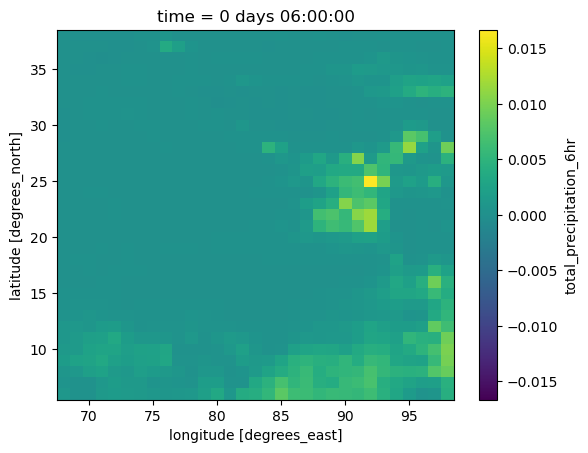

In [58]:
predictions_finetuned.isel(time=0).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax))['total_precipitation_6hr'].plot(cmap='viridis')

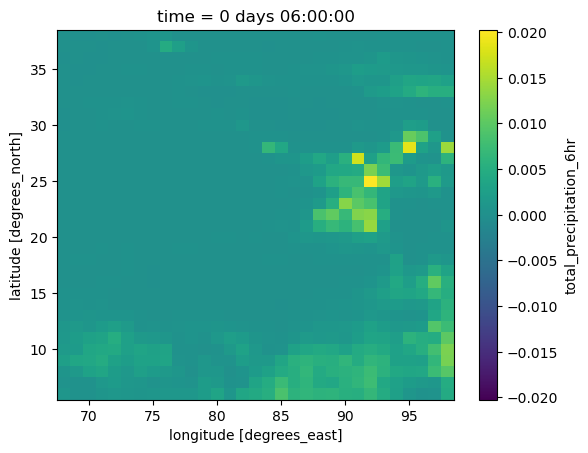

In [70]:
predictions_old.isel(time=0).sel(lat=slice(latmax, latmin), lon=slice(lonmin, lonmax))['total_precipitation_6hr'].plot(cmap='viridis')

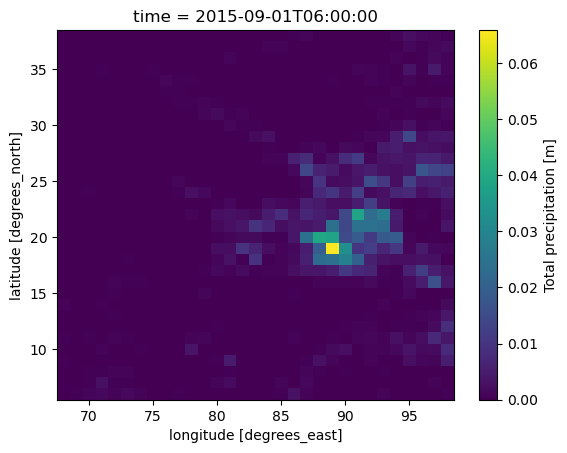

In [68]:
imerg_test.isel(time=0).sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax))['total_precipitation_6hr'].plot(cmap='viridis')

In [71]:
diff_base = []
diff_fine = []
for i in tqdm(range(7)):
    diff_fine.append(plot_difference_with_targets_fine(predictions_finetuned, imerg_test, i, 'total_precipitation_6hr'))
    diff_base.append(plot_difference_with_targets_base(predictions_old, imerg_test, i, 'total_precipitation_6hr'))


100%|██████████| 7/7 [00:01<00:00,  4.38it/s]


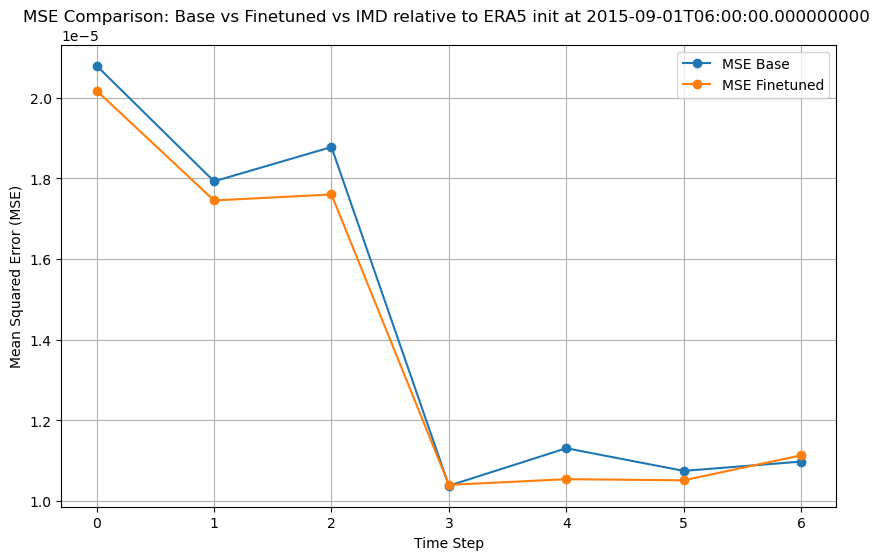

<Figure size 640x480 with 0 Axes>

In [73]:
def compute_mse(predictions, targets):
        return ((predictions - targets) ** 2).mean()

def compute_mse_diffs(diff):
    return (diff ** 2).mean(dim=["lat", "lon"]).values

# Compute the MSE for each time step and aggregate
mse_finetuned = []
mse_base = []
mse_imd_era5 = []
for j in range(len(diff_fine)):
    mse_diff_finetuned = compute_mse_diffs(diff_fine[j])
    mse_diff_base = compute_mse_diffs(diff_base[j])
    # mse_diff_imd_era5 = compute_mse_diffs(differences_era5_imd[i])
    
    mse_finetuned.append(mse_diff_finetuned)
    mse_base.append(mse_diff_base)

# print(mse_base)
# print()
# print(mse_finetuned)




# Plot the line chart
plt.figure(figsize=(10, 6))
plt.plot(list(range(7)), mse_base, label='MSE Base', marker='o')
plt.plot(list(range(7)), mse_finetuned, label='MSE Finetuned', marker='o')
# plt.plot(time_steps, mse_imd_era5, label='MSE IMD ERA5', marker='x')

    # Annotate the first and last points for MSE Base
# plt.annotate(f"{mse_base[0]:.4f}", (0, mse_base[0]), textcoords="offset points", xytext=(-10, 10), ha='center')
# plt.annotate(f"{mse_base[-1]:.4f}", (6, mse_base[-1]), textcoords="offset points", xytext=(-10, 10), ha='center')


# Add labels, title, and legend
plt.xlabel('Time Step')
plt.ylabel('Mean Squared Error (MSE)')
plt.title(f'MSE Comparison: Base vs Finetuned vs IMD relative to ERA5 init at {imerg_test.time.values[0]} ')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()
# plt.savefig(f"./final_plots/metrics/mse_comparison_finetuned_base_{i}_{current_date}.png")
plt.clf()
